In [1]:
import pandas as pd
import numpy as np

history_prefix = "training_history_"

# Combining data

In [2]:
import os
import glob
import re

# Define the path to the mirt-fitting results
results_path = "/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/result/mirt-fitting"

# Get all CSV files starting with the history prefix and containing any k-factor
csv_pattern = os.path.join(results_path, f"{history_prefix}*_k*.csv")
csv_files = glob.glob(csv_pattern)

print(f"Found {len(csv_files)} CSV files with prefix '{history_prefix}' and k-factors")

# List to store individual dataframes
dataframes = []

# Read each CSV file and add scenario column
for csv_file in csv_files:
    # Extract filename without path
    filename = os.path.basename(csv_file)
    
    # Extract k-factor from filename
    k_match = re.search(r'_k(\d+)', filename)
    if not k_match:
        continue  # Skip files without k-factor
    
    k_factor = int(k_match.group(1))
    
    # Extract scenario name: remove prefix and k-factor suffix
    scenario = filename.replace(history_prefix, "").replace(".csv", "")
    scenario = re.sub(r'_k\d+$', '', scenario)  # Remove _k followed by digits
    
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Add scenario and k_factor columns
    df['scenario'] = scenario
    df['k_factor'] = k_factor
    
    # Add to list
    dataframes.append(df)
    
# Combine all dataframes
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined DataFrame shape: {combined_df.shape}")
print(f"Unique scenarios: {combined_df['scenario'].nunique()}")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Scenarios: {sorted(combined_df['scenario'].unique())}")

# Display first few rows
print("\nFirst 5 rows of combined data:")
combined_df.head()

Found 230 CSV files with prefix 'training_history_' and k-factors



Combined DataFrame shape: (44403, 5)
Unique scenarios: 23
Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Scenarios: ['air_bench_2024', 'babi_qa', 'bbq', 'boolq', 'civil_comments', 'combined_data', 'commonsense', 'dyck_language_np=3', 'entity_data_imputation', 'entity_matching', 'gsm', 'imdb', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'med_qa', 'mmlu', 'raft', 'synthetic_reasoning', 'thai_exam', 'truthful_qa', 'wikifact']

First 5 rows of combined data:


,epoch,train_loss,val_auc,scenario,k_factor
0,1,0.861705,0.504546,air_bench_2024,1
1,2,0.843249,0.511407,air_bench_2024,1
2,3,0.826507,0.518543,air_bench_2024,1
3,4,0.810855,0.525944,air_bench_2024,1
4,5,0.796177,0.533587,air_bench_2024,1


In [3]:
combined_df.groupby('scenario').size()

scenario
air_bench_2024            1070
babi_qa                   1658
bbq                       2815
boolq                     1254
civil_comments             414
combined_data              272
commonsense               2539
dyck_language_np=3        3499
entity_data_imputation    2813
entity_matching           2011
gsm                       1621
imdb                      1473
legal_support             2621
legalbench                1589
lsat_qa                   3889
math                      2301
med_qa                    1675
mmlu                       526
raft                      2461
synthetic_reasoning       1399
thai_exam                 2472
truthful_qa               2870
wikifact                  1161
dtype: int64

In [4]:
# Check what k-factors we have in the raw data
print("K-factors in raw combined_df:")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Count by k-factor:")
print(combined_df['k_factor'].value_counts().sort_index())
print(f"\nScenarios by k-factor:")
for k in sorted(combined_df['k_factor'].unique()):
    scenarios = combined_df[combined_df['k_factor'] == k]['scenario'].nunique()
    print(f"k={k}: {scenarios} scenarios")

K-factors in raw combined_df:
Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Count by k-factor:
k_factor
1     4908
2     5268
3     4851
4     4722
5     4648
6     4359
7     4118
8     3695
9     3925
10    3909
Name: count, dtype: int64

Scenarios by k-factor:
k=1: 23 scenarios
k=2: 23 scenarios
k=3: 23 scenarios
k=4: 23 scenarios
k=5: 23 scenarios
k=6: 23 scenarios
k=7: 23 scenarios
k=8: 23 scenarios
k=9: 23 scenarios
k=10: 23 scenarios


In [5]:
# Group by both scenario and k_factor, then take max values for each combination
combined_df = combined_df.groupby(['scenario', 'k_factor']).max().reset_index()

print(f"After groupby - Shape: {combined_df.shape}")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Scenarios per k-factor:")
print(combined_df.groupby('k_factor')['scenario'].nunique())

After groupby - Shape: (230, 5)
Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Scenarios per k-factor:
k_factor
1     23
2     23
3     23
4     23
5     23
6     23
7     23
8     23
9     23
10    23
Name: scenario, dtype: int64


In [6]:
# Index is already reset in the previous cell
combined_df.head()

,scenario,k_factor,epoch,train_loss,val_auc
0,air_bench_2024,1,130,0.861705,0.909543
1,air_bench_2024,2,120,0.984802,0.915069
2,air_bench_2024,3,124,1.063845,0.915235
3,air_bench_2024,4,144,1.138791,0.911684
4,air_bench_2024,5,99,1.207393,0.910692


In [7]:
# Create DataFrame with the model results
results_data = {
    'scenario': [
        'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
        'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support', 'civil_comments',
        'legalbench', 'raft', 'air_bench_2024', 'math', 'med_qa', 'gsm',
        'boolq', 'mmlu', 'entity_matching', 'entity_data_imputation',
        'commonsense', 'imdb', 'combined_data'
    ],
    'train_auc': [
        0.688523530960083, 0.7754234075546265, 0.8787771463394165, 0.8385953307151794, 0.8949015140533447,
        0.7257800102233887, 0.857973575592041, 0.7987954020500183, 0.7143356800079346, 0.7923104763031006,
        0.8490860462188721, 0.8433337211608887, 0.9189774990081787, 0.9069100618362427, 0.8781333565711975,
        0.9062897562980652, 0.8516445159912109, 0.9107261896133423, 0.9005221128463745, 0.9436786770820618,
        0.9296308755874634, 0.9275050163269043, 0.8401544094085693
    ],
    'test_auc': [
        0.6194833517074585, 0.752168595790863, 0.8685898780822754, 0.825733482837677, 0.8836542367935181,
        0.6776220798492432, 0.8284746408462524, 0.7705100774765015, 0.6697757244110107, 0.774608314037323,
        0.836212158203125, 0.8359396457672119, 0.9038318991661072, 0.8989916443824768, 0.869013786315918,
        0.8985381722450256, 0.833503007888794, 0.8993809223175049, 0.8869590759277344, 0.9344797134399414,
        0.9203937649726868, 0.8829501271247864, 0.8265177607536316
    ],
    'train_cttcorr': [
        0.9999999954797291, 0.9999999890694462, 0.9999999995909886, 0.9999999976074504, 0.9999999986407333,
        0.9999999872610216, 0.9999999915025175, 0.99999999921584, 0.9999999976040401, 0.9999999982895018,
        0.9999999853873718, 0.9999999898960499, 0.9999999965323432, 0.9999999994130362, 0.9999999955530873,
        0.9999999995129949, 0.9999999996984892, 0.999999994816744, 0.9999999996850908, 0.9999999995785793,
        0.9999999981061295, 0.9999999868962981, 0.9999982965698357
    ],
    'test_cttcorr': [
        0.5906119125422994, 0.9706165826374094, 0.9944507503020064, 0.9801349393837014, 0.9955563464912967,
        0.9853548320237024, 0.9473795683343597, 0.9523431791191582, 0.8647175288487944, 0.9993321449878049,
        0.9853292991185817, 0.9667072922095117, 0.9979504514385135, 0.9904288659823243, 0.9823410596225498,
        0.9927657682987716, 0.993096924815468, 0.9973090123780943, 0.996777295569847, 0.96432828871636,
        0.9816468838401071, 0.9922439784181618, 0.9927450093359975
    ]
}

# Create the results DataFrame
results_df = pd.DataFrame(results_data)

In [8]:
resmat = pd.read_pickle('../data/resmat.pkl')

In [9]:
counts_dict = resmat.columns.get_level_values('scenario').value_counts().dropna()
scenario_sizes = {fruit: count for fruit, count in counts_dict.items() if count > 0}
scenario_sizes

{'civil_comments': 29407,
 'mmlu': 13223,
 'wikifact': 5511,
 'air_bench_2024': 4985,
 'imdb': 3530,
 'babi_qa': 3461,
 'boolq': 3316,
 'synthetic_reasoning': 2234,
 'legalbench': 1997,
 'truthful_qa': 1888,
 'entity_matching': 1396,
 'raft': 1336,
 'bbq': 999,
 'med_qa': 998,
 'gsm': 997,
 'legal_support': 594,
 'thai_exam': 557,
 'dyck_language_np=3': 500,
 'commonsense': 498,
 'lsat_qa': 454,
 'math': 436,
 'entity_data_imputation': 395}

In [10]:


# Create a DataFrame with scenario sizes
size_df = pd.DataFrame(list(scenario_sizes.items()), columns=['scenario', 'size'])
print("Scenario sizes:")
print(size_df.sort_values('size', ascending=False))

Scenario sizes:
                  scenario   size
0           civil_comments  29407
1                     mmlu  13223
2                 wikifact   5511
3           air_bench_2024   4985
4                     imdb   3530
5                  babi_qa   3461
6                    boolq   3316
7      synthetic_reasoning   2234
8               legalbench   1997
9              truthful_qa   1888
10         entity_matching   1396
11                    raft   1336
12                     bbq    999
13                  med_qa    998
14                     gsm    997
15           legal_support    594
16               thai_exam    557
17      dyck_language_np=3    500
18             commonsense    498
19                 lsat_qa    454
20                    math    436
21  entity_data_imputation    395


In [11]:
# Merge the results DataFrame with the combined training history DataFrame
merged_df = combined_df.merge(results_df, on='scenario', how='left')

# Also merge with size information
merged_df = merged_df.merge(size_df, on='scenario', how='left')

print(f"Merged DataFrame shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")

# Check for any scenarios that didn't match
scenarios_in_combined = set(combined_df['scenario'].unique())
scenarios_in_results = set(results_df['scenario'].unique())
scenarios_in_sizes = set(size_df['scenario'].unique())

print(f"\nScenarios in combined_df: {len(scenarios_in_combined)}")
print(f"Scenarios in results_df: {len(scenarios_in_results)}")
print(f"Scenarios in size_df: {len(scenarios_in_sizes)}")
print(f"Scenarios in all: {len(scenarios_in_combined.intersection(scenarios_in_results).intersection(scenarios_in_sizes))}")

if scenarios_in_combined - scenarios_in_results:
    print(f"Scenarios in combined_df but not in results_df: {scenarios_in_combined - scenarios_in_results}")
if scenarios_in_results - scenarios_in_combined:
    print(f"Scenarios in results_df but not in combined_df: {scenarios_in_results - scenarios_in_combined}")
if scenarios_in_combined - scenarios_in_sizes:
    print(f"Scenarios in combined_df but not in size_df: {scenarios_in_combined - scenarios_in_sizes}")

Merged DataFrame shape: (230, 10)
Columns: ['scenario', 'k_factor', 'epoch', 'train_loss', 'val_auc', 'train_auc', 'test_auc', 'train_cttcorr', 'test_cttcorr', 'size']

Scenarios in combined_df: 23
Scenarios in results_df: 23
Scenarios in size_df: 22
Scenarios in all: 22
Scenarios in combined_df but not in size_df: {'combined_data'}


In [12]:
# Prepare data for plotting - include k_factor information
df = merged_df[['val_auc', 'test_auc', 'scenario', 'k_factor', 'size']].sort_values(by='test_auc', ascending=True).dropna().copy()
df.rename(columns={'val_auc': 'mirt', 'test_auc': 'irt'}, inplace=True)

# Show unique k-factors available
print(f"Available k-factors: {sorted(df['k_factor'].unique())}")
print(f"Data shape: {df.shape}")
df.head()

Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Data shape: (220, 5)


,mirt,irt,scenario,k_factor,size
144,0.844361,0.619483,lsat_qa,5,454.0
145,0.830923,0.619483,lsat_qa,6,454.0
146,0.828669,0.619483,lsat_qa,7,454.0
147,0.824287,0.619483,lsat_qa,8,454.0
143,0.839630,0.619483,lsat_qa,4,454.0


In [13]:
df.to_pickle('../data/calibration_results.pkl')

# Model fit assessment

In [1]:
import pandas as pd

df = pd.read_pickle('../data/calibration_results.pkl')

/tmp/ipykernel_10267/207101899.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


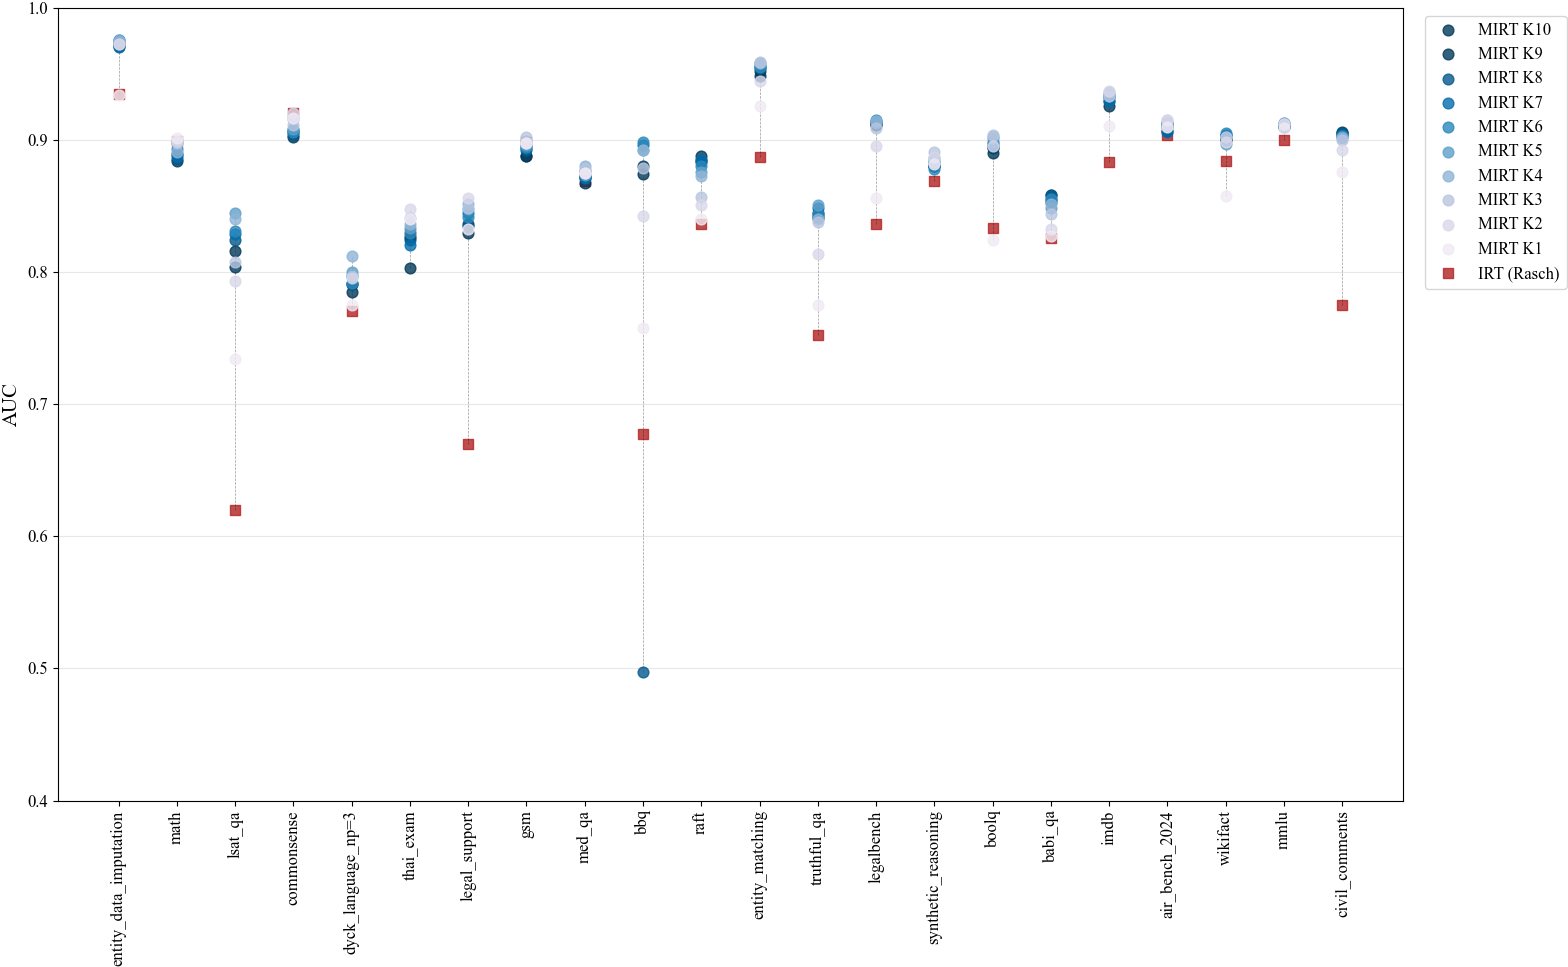

In [2]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Create the transposed dumbbell plot with k-factor colors, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('PuBu')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# Plot for each k-factor
for k_factor in reversed(k_factors):
	df_k = df[df['k_factor'] == k_factor]
	
	if len(df_k) == 0:
		continue
	
	# Get x positions for this k-factor's scenarios
	x_positions = [x_pos[scenario] for scenario in df_k['scenario']]
	
	# Plot the MIRT points
	ax.scatter(x_positions, df_k['mirt'], 
			  color=color_map[k_factor], s=60, 
			  label=f'MIRT K{k_factor}', 
			  marker='o', alpha=0.8, zorder=3)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario (they should be the same across k-factors)
df_irt = df.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between lowest and highest values for each scenario
for scenario in scenarios:
	df_scenario = df[df['scenario'] == scenario]
	if len(df_scenario) == 0:
		continue
	
	x = x_pos[scenario]
	
	# Get all values (both IRT and MIRT) for this scenario
	all_values = list(df_scenario['mirt']) + [df_scenario['irt'].iloc[0]]
	
	# Find min and max values
	min_val = min(all_values)
	max_val = max(all_values)
	
	# Draw line from lowest to highest value
	ax.plot([x, x], [min_val, max_val], 'k--', linewidth=0.5, alpha=0.4)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10267/1056642770.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


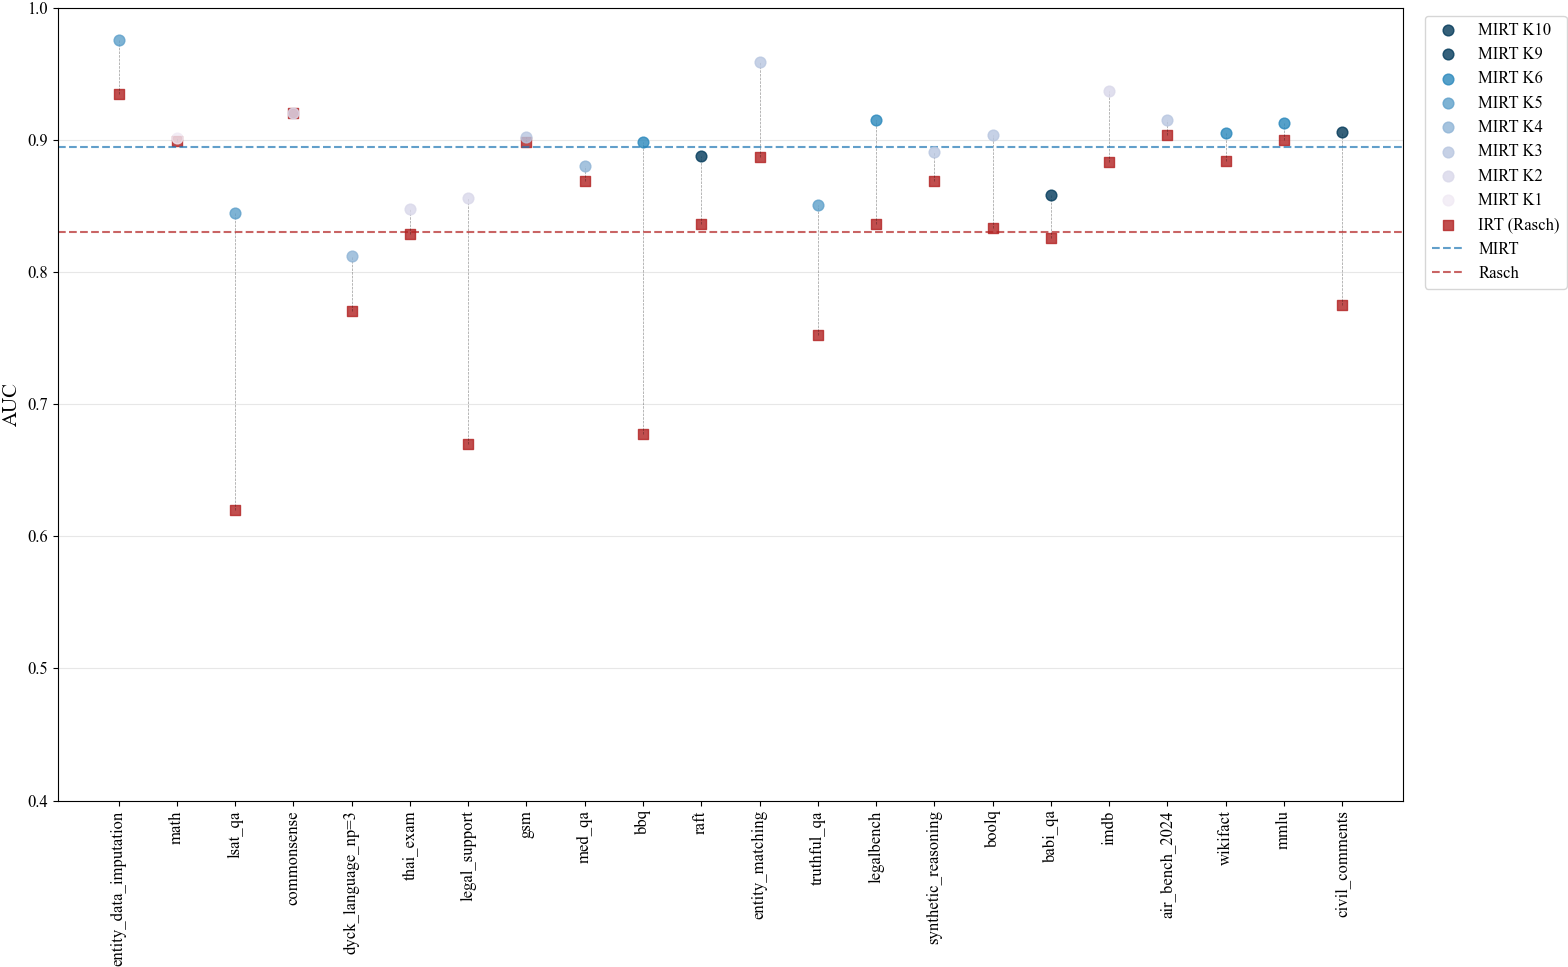

In [3]:
# Create simplified plot showing only IRT and highest MIRT AUC, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))
# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df['k_factor'].unique())

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# For each scenario, find the highest MIRT AUC across all k-factors
highest_mirt_data = []
for scenario in scenarios:
    df_scenario = df[df['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Find the row with the highest MIRT AUC for this scenario
        max_mirt_row = df_scenario.loc[df_scenario['mirt'].idxmax()]
        highest_mirt_data.append({
            'scenario': scenario,
            'mirt': max_mirt_row['mirt'],
            'k_factor': max_mirt_row['k_factor'],
            'irt': max_mirt_row['irt'],
            'size': max_mirt_row['size']
        })

# Convert to DataFrame for easier handling
highest_mirt_df = pd.DataFrame(highest_mirt_data)

# Create the same color map as before
colors = plt.get_cmap('PuBu')
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Get unique k-factors that actually appear as highest performers
highest_k_factors = sorted(highest_mirt_df['k_factor'].unique())

# Plot the highest MIRT points grouped by k-factor for legend purposes
plotted_k_factors = set()
for k_factor in reversed(highest_k_factors):
    # Get all scenarios where this k-factor is the highest performer
    k_data = highest_mirt_df[highest_mirt_df['k_factor'] == k_factor]
    
    x_positions = [x_pos[scenario] for scenario in k_data['scenario']]
    
    # Plot points for this k-factor
    ax.scatter(x_positions, k_data['mirt'], 
              color=color_map[k_factor], s=60, 
              label=f'MIRT K{k_factor}', 
              marker='o', alpha=0.8, zorder=3)
    
    plotted_k_factors.add(k_factor)

# Plot IRT (Rasch) points - same as before
df_irt = df.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between IRT and highest MIRT for each scenario
for _, row in highest_mirt_df.iterrows():
    x = x_pos[row['scenario']]
    
    # Draw line between IRT and highest MIRT value
    ax.plot([x, x], [row['irt'], row['mirt']], 'k--', linewidth=0.5, alpha=0.4)

# Calculate and plot average lines
mirt_avg = highest_mirt_df['mirt'].mean()
irt_avg = df_irt['irt'].mean()

# Add horizontal lines for averages
ax.axhline(y=mirt_avg, color='C0', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'MIRT', zorder=2)
ax.axhline(y=irt_avg, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Rasch', zorder=2)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10267/799792649.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


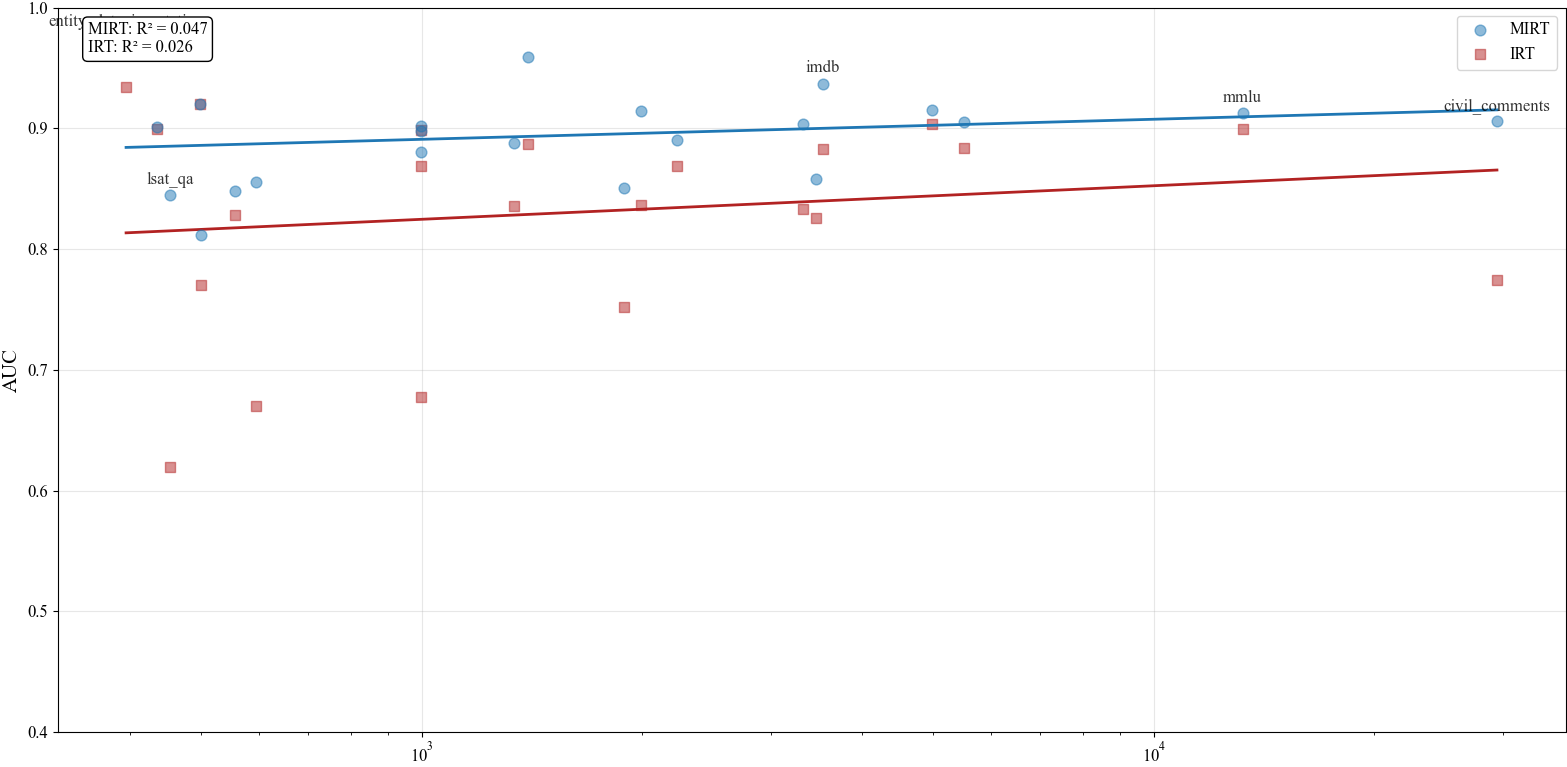

In [4]:
# Create scatter plot: Dataset Size vs AUC Performance
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data for the size vs AUC plot
# Get highest MIRT performance for each scenario
size_auc_data = []
for scenario in df['scenario'].unique():
    df_scenario = df[df['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Get the highest MIRT AUC for this scenario
        max_mirt_row = df_scenario.loc[df_scenario['mirt'].idxmax()]
        
        size_auc_data.append({
            'scenario': scenario,
            'size': max_mirt_row['size'],
            'mirt_highest': max_mirt_row['mirt'],
            'irt': max_mirt_row['irt']
        })

# Convert to DataFrame
size_auc_df = pd.DataFrame(size_auc_data)

# Sort by size for cleaner plotting
size_auc_df = size_auc_df.sort_values('size')

# Plot scatter points
ax.scatter(size_auc_df['size'], size_auc_df['mirt_highest'], 
          color='C0', s=60, alpha=0.5, label='MIRT', zorder=3)
ax.scatter(size_auc_df['size'], size_auc_df['irt'], marker='s',
          color='firebrick', s=60, alpha=0.5, label='IRT', zorder=2)

# Fit and plot trend lines
# MIRT trend line
mirt_slope, mirt_intercept, mirt_r, _, _ = stats.linregress(np.log10(size_auc_df['size']), size_auc_df['mirt_highest'])
x_trend = np.logspace(np.log10(size_auc_df['size'].min()), np.log10(size_auc_df['size'].max()), 100)
mirt_trend = mirt_slope * np.log10(x_trend) + mirt_intercept
ax.plot(x_trend, mirt_trend, color='C0', linestyle='-', linewidth=2, alpha=1, zorder=2)

# IRT trend line
irt_slope, irt_intercept, irt_r, _, _ = stats.linregress(np.log10(size_auc_df['size']), size_auc_df['irt'])
irt_trend = irt_slope * np.log10(x_trend) + irt_intercept
ax.plot(x_trend, irt_trend, color='firebrick', linestyle='-', linewidth=2, alpha=1, zorder=2)

# Add scenario labels for key points
for _, row in size_auc_df.iterrows():
	# Label only some scenarios to avoid clutter
	if row['scenario'] in ['civil_comments', 'entity_data_imputation', 'lsat_qa', 'mmlu', 'imdb']:
		ax.annotate(row['scenario'], 
				   (row['size'], row['mirt_highest']), 
				   xytext=(0, 8), textcoords='offset points', 
				   fontsize=12, alpha=0.8, ha='center')

# Customize the plot
ax.set_xscale('log')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.0)

# Add correlation info
ax.text(0.02, 0.98, f'MIRT: R² = {mirt_r**2:.3f}\nIRT: R² = {irt_r**2:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=1))

plt.tight_layout()
plt.show()

# Interpretability check
`lsat_qa` with k=2

In [78]:
from load_params import load_and_rotate
import pandas as pd
import sys
sys.path.append('..') 
import style
# Concatenate math and gsm outputs for theta, a, b
theta_math, a_math, b_math = load_and_rotate('../result/mirt-fitting/mirt_model_k2_math.pt', rotation=None)
theta_gsm, a_gsm, b_gsm = load_and_rotate('../result/mirt-fitting/mirt_model_k2_gsm.pt', rotation=None)

theta = np.concatenate([theta_math, theta_gsm], axis=0)
a = np.concatenate([a_math, a_gsm], axis=0)
b = np.concatenate([b_math, b_gsm], axis=0)

resmat = pd.read_pickle('../data/resmat.pkl')

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (436, 2)
Loaded cached b shape: (436,)

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (997, 2)
Loaded cached b shape: (997,)



In [79]:
conv = ['math', 'gsm']

conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()


theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
a_df = pd.DataFrame(a, columns=[f'Factor_{i+1}' for i in range(a.shape[1])])
a_df['question'] = conv_questions

ValueError: Shape of passed values is (366, 2), indices imply (183, 2)

In [ ]:
with pd.option_context('display.max_rows', 10):
	display(a_df.sort_values('Factor_1', ascending=False).head(100))

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,question
290,2.683673,0.249631,-2.840924,-1.501533,1.431271,"Exactly eight books—F, G, H, I, K, L, M, O—are..."
40,2.095465,0.886402,-0.430335,0.029509,2.536498,A concert is given by a six-member band—guitar...
414,2.011203,0.308399,-2.141360,-1.023512,1.824793,"Six park rangers—Jefferson, Koguchi, Larson, M..."
288,2.005809,-0.139067,-1.592796,-1.113999,1.122630,"Exactly eight books—F, G, H, I, K, L, M, O—are..."
292,1.929246,1.319723,-2.624288,-0.115917,1.356600,Exactly five movies are showing at the reperto...
...,...,...,...,...,...,...
430,0.468971,0.157802,-1.962050,-0.120242,-0.192991,The organizer of a luncheon will select exactl...
211,0.444670,0.023042,-1.523758,-0.791958,1.809069,At a business symposium there will be exactly ...
433,0.442918,0.305173,-1.472224,-0.425800,0.522218,The organizer of a reading club will select at...
217,0.439334,-1.035138,-0.445768,1.667642,0.545122,"At a children's festival, exactly four songs a..."


In [ ]:
models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df.rename(columns={'Factor_1': 'F1:recollection', 'Factor_2': 'F2:application'}, inplace=True)

In [ ]:
with pd.option_context('display.max_rows', 10):
	display(theta_df.loc[models_answered].sort_values('accuracy', ascending=False).head(100))

,F1:recollection,F2:application,Factor_3,Factor_4,Factor_5,accuracy
request.model,,,,,,
together/redpajama-incite-instruct-7b,-1.165371,-1.196137,3.143562,0.802216,-0.044545,0.242291
openai/text-davinci-003,1.273624,0.464949,1.755576,-1.460495,-0.035006,0.237885
tiiuae/falcon-7b,-0.716561,-3.945381,0.552106,-0.044744,-0.425157,0.237885
writer/palmyra-x,0.571876,-0.512938,1.277291,-1.575436,0.265891,0.229075
openai/babbage,0.238616,-1.489161,-0.105656,0.149940,-0.054616,0.224670
...,...,...,...,...,...,...
lmsys/vicuna-7b-v1.3,1.230409,-0.309242,1.316849,0.014886,-0.424768,0.174009
meta/llama-2-7b,0.656841,-0.539381,0.462091,1.478880,-0.803887,0.165198
openai/gpt-3.5-turbo-0613,-1.107735,-1.366185,1.578030,-0.872966,-1.486490,0.143172


In [ ]:
import numpy as np
from numpy.polynomial.hermite import hermgauss

def compute_eap_map_sd(Y, A, b, n_points=21):
    """
    Compute 2D EAP, MAP, and posterior SD estimates using Gauss-Hermite quadrature.

    Parameters
    ----------
    Y : array (n_persons, n_items)
        Binary response matrix.
    A : array (n_items, k)
        Discrimination/loadings matrix.
    b : array (n_items,)
        Difficulty parameters.
    n_points : int
        Number of quadrature nodes per dimension.

    Returns
    -------
    eap_scores : array (n_persons, k)
        EAP ability estimates.
    map_scores : array (n_persons, k)
        MAP ability estimates.
    sd_scores : array (n_persons, k)
        Posterior standard deviation (uncertainty) estimates.
    """

    n_persons, n_items = Y.shape
    k = A.shape[1]
    assert k == 2, "This function is written for K=2."

    # 1. Gauss–Hermite quadrature nodes & weights
    nodes_1d, weights_1d = hermgauss(n_points)
    nodes_1d = nodes_1d * np.sqrt(2)       # rescale for N(0,1)
    weights_1d = weights_1d / np.sqrt(np.pi)

    # 2. Tensor grid for k=2
    grid = np.array(np.meshgrid(nodes_1d, nodes_1d)).T.reshape(-1, k)    # (n_points^2, 2)
    weights = np.outer(weights_1d, weights_1d).ravel()                   # (n_points^2,)

    # 3. Precompute item probabilities at all grid points
    linpred = (A @ grid.T).T - b    # (n_points^2, n_items)
    P = 1 / (1 + np.exp(-linpred))  # logistic

    # Allocate storage
    eap_scores = np.zeros((n_persons, k))
    map_scores = np.zeros((n_persons, k))
    sd_scores  = np.zeros((n_persons, k))

    # 4. Loop over persons
    for i in range(n_persons):
        y = Y[i]  # (n_items,)

        # Log-likelihood for each grid point
        loglike = np.sum(
            y * np.log(P + 1e-12) + (1 - y) * np.log(1 - P + 1e-12),
            axis=1
        )

        # Posterior (log-sum-exp for stability)
        post = np.exp(loglike - loglike.max()) * weights
        if np.sum(post) == 0:  # safeguard for numerical underflow
            post = np.ones_like(post) / len(post)
        else:
            post /= np.sum(post)

        # --- EAP ---
        eap = np.sum(grid * post[:, None], axis=0)
        eap_scores[i] = eap

        # --- Posterior variance & SD ---
        second_moment = np.sum((grid**2) * post[:, None], axis=0)
        var = second_moment - eap**2
        sd_scores[i] = np.sqrt(np.maximum(var, 0.0))

        # --- MAP ---
        map_scores[i] = grid[np.argmax(post)]

    return eap_scores, map_scores, sd_scores


In [ ]:
# Example shapes
Y = conv_mask.dropna(how='all').values
A = a_df.select_dtypes(include=[np.number]).values

eap, map_, sd = compute_eap_map_sd(Y, A, b, n_points=21)

print("EAP scores shape:", eap.shape)  # (60, 2)
print("MAP scores shape:", map_.shape) # (60, 2)
print("SD shape:", sd.shape)     # (60, 2)


print("First 3 persons EAP:\n", eap[:3])
print("First 3 persons MAP:\n", map_[:3])
print("First 3 person posterior SD:", sd[:3])


AssertionError: This function is written for K=2.

In [ ]:
import numpy as np
from factor_analyzer.rotator import Rotator

# Suppose A is your discrimination matrix (500 × 2)
rotator = Rotator(method="varimax")   # or "oblimin"
A_rot = rotator.fit_transform(A)

# Rotation matrix R can be retrieved
R = rotator.rotation_

# Apply the same rotation to person scores
eap_rot = eap @ R
map_rot = map_ @ R


Dim 1: Pearson r = 0.9970 (p=4.95e-76)
Dim 2: Pearson r = 0.9942 (p=1.09e-66)


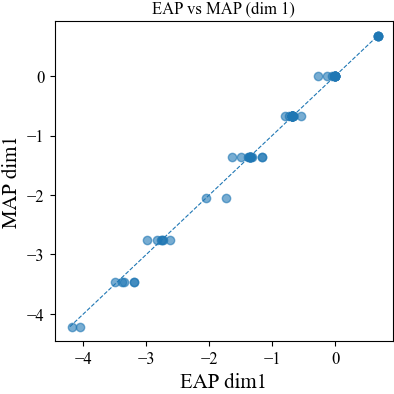

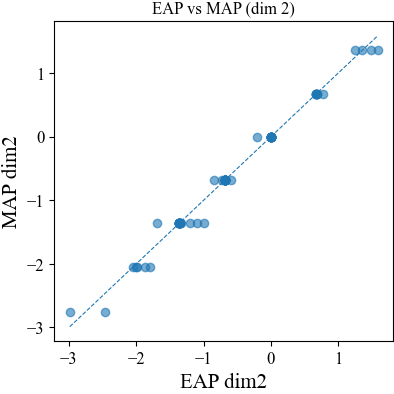

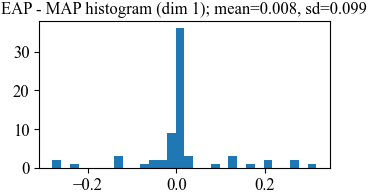

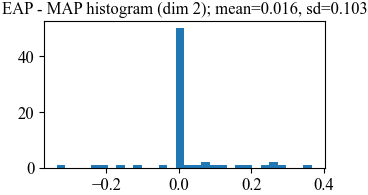

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1) Correlation between EAP and MAP per dimension
for dim in range(eap.shape[1]):
    r, p = stats.pearsonr(eap[:,dim], map_[:,dim])
    print(f"Dim {dim+1}: Pearson r = {r:.4f} (p={p:.3g})")

# 2) Scatterplot EAP vs MAP for each dimension
for dim in range(eap.shape[1]):
    plt.figure(figsize=(4,4))
    plt.scatter(eap[:,dim], map_[:,dim], alpha=0.6)
    mn = min(eap[:,dim].min(), map_[:,dim].min())
    mx = max(eap[:,dim].max(), map_[:,dim].max())
    plt.plot([mn,mx],[mn,mx], '--', linewidth=0.8)  # y=x
    plt.xlabel(f"EAP dim{dim+1}")
    plt.ylabel(f"MAP dim{dim+1}")
    plt.title(f"EAP vs MAP (dim {dim+1})")
    plt.show()

# 3) Bland-Altman style: distribution of differences
diff = eap - map_
for dim in range(eap.shape[1]):
    plt.hist(diff[:,dim], bins=30)
    plt.title(f"EAP - MAP histogram (dim {dim+1}); mean={diff[:,dim].mean():.3f}, sd={diff[:,dim].std():.3f}")
    plt.show()


In [ ]:
a_df['Factor_1'] = A_rot[:,0]
a_df['Factor_2'] = A_rot[:,1]
a_df


,Factor_1,Factor_2,question
0,0.547083,2.601420,A bakery makes exactly three kinds of cookie—o...
1,1.670193,1.006320,A bakery makes exactly three kinds of cookie—o...
2,2.936575,0.497433,A bakery makes exactly three kinds of cookie—o...
3,0.412803,-0.035855,A bakery makes exactly three kinds of cookie—o...
4,-0.145209,1.431772,A bakery makes exactly three kinds of cookie—o...
...,...,...,...
449,2.464650,3.001032,Three rugs will be woven out of colored thread...
450,0.145506,2.359782,Three rugs will be woven out of colored thread...
451,0.888739,-0.640053,Three rugs will be woven out of colored thread...
452,-0.212054,2.580647,Three rugs will be woven out of colored thread...


In [ ]:
a_df.to_csv('conv_item_loadings_rotated.csv', index=False)